In [1]:
from datetime import datetime, timedelta
from functools import partial
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import talib

from samples.myStrategy import myStrategy as baseline_strategy

## Load Data

In [2]:
path = 'data/0050.TW.csv'
df = pd.read_csv(path)

adj_close = df['Adj Close']
date = df['Date']
date_set = set(date)
date_idx = pd.Index(date)

## Analysis

In [3]:
def set_title(beg_idx: int, end_idx: int):
  day_num = end_idx - beg_idx + 1
  title = f'{date[beg_idx]} ~ {date[end_idx]}\n{day_num} trade days'
  plt.title(title, fontsize=10)

In [4]:
def plot_rsi(
  close_price: np.ndarray,
  short_period: int, long_period: int
):
  fast = talib.RSI(close_price, timeperiod=short_period)
  slow = talib.RSI(close_price, timeperiod=long_period)

  plt.plot(fast, 'tab:orange')
  plt.plot(slow, 'tab:blue')

def plot_macd(
    close_price: np.ndarray,
    short_period: int, long_period: int, signal_period: int
):
  macd, signal, _ = talib.MACD(close_price, short_period, long_period, signal_period)

  plt.plot(macd, 'tab:blue')
  plt.plot(signal, 'tab:orange')

In [5]:
def plot_actions(close_price: np.ndarray, actions: list):
  buy = []
  sell = []

  for i, action in enumerate(actions):
    if action == 1:
      buy.append(close_price[i])
      sell.append(None)
    elif action == -1:
      buy.append(None)
      sell.append(close_price[i])
    else:
      buy.append(None)
      sell.append(None)

  plt.plot(buy, color='red', marker='^')
  plt.plot(sell, color='green', marker='v')

In [6]:
def get_nearest_workday_idx(date_str: str) -> int:
  ori_date = datetime.strptime(date_str, '%Y-%m-%d')
  date = ori_date

  delta_days = 1

  while date.strftime('%Y-%m-%d') not in date_set:
    date = ori_date + timedelta(days=delta_days)
    delta_days = -delta_days if delta_days > 0 else (-delta_days + 1)

  idx = date_idx.get_loc(date.strftime('%Y-%m-%d'))

  return idx

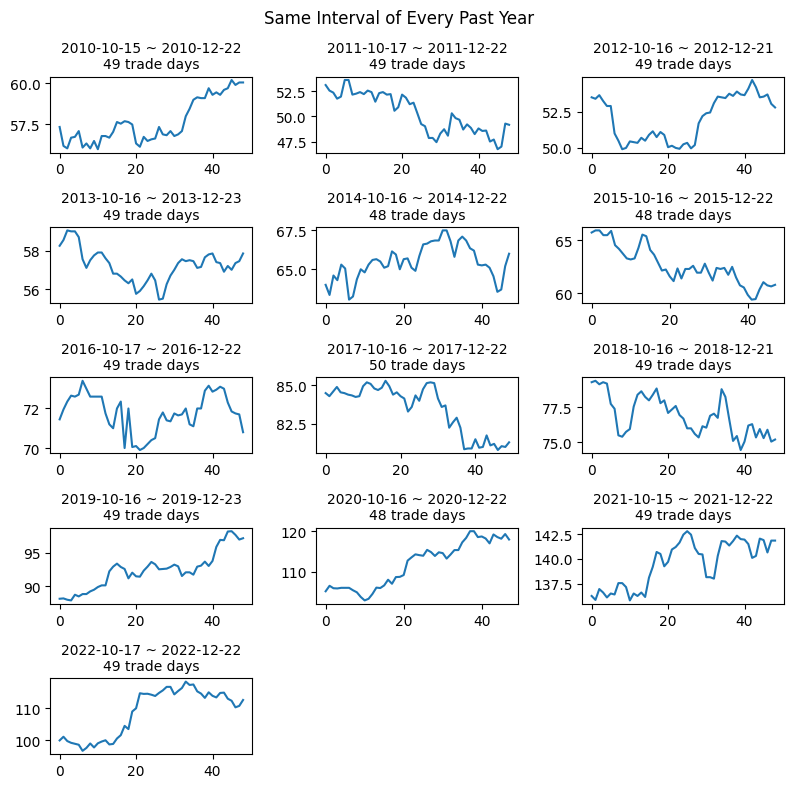

In [7]:
fig = plt.figure(figsize=(8, 8))

for y in range(2010, 2023):
  beg_idx = get_nearest_workday_idx(f'{y}-10-16')
  end_idx = get_nearest_workday_idx(f'{y}-12-22')
  close_price = adj_close[beg_idx:end_idx + 1].values

  plt.subplot(5, 3, y - 2009)
  set_title(beg_idx, end_idx)
  plt.plot(close_price)

plt.suptitle('Same Interval of Every Past Year')
plt.tight_layout()
plt.show()

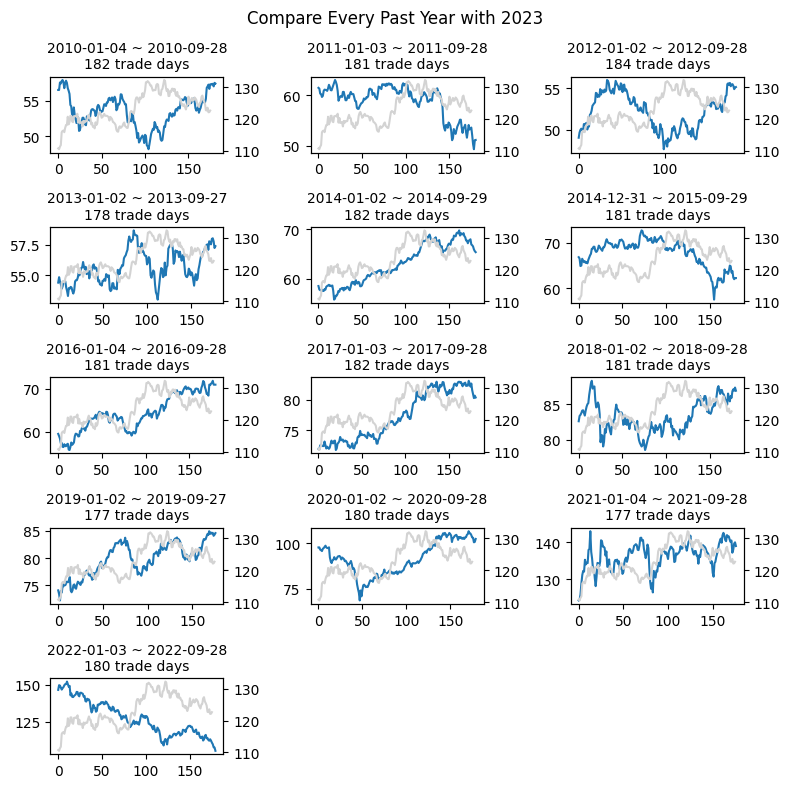

,rho
2017,0.741840
2014,0.727851
2016,0.578945
2019,0.442797
2021,0.404455
2020,0.308456
2013,0.244935
2018,0.096982
2015,-0.180495
2011,-0.237876


In [8]:
fig = plt.figure(figsize=(8, 8))

beg_idx = date_idx.get_loc('2023-01-03')
end_idx = date_idx.get_loc('2023-09-28')
close_price_2023 = adj_close[beg_idx:end_idx + 1].values

corr_list = pd.Series()

for y in range(2010, 2023):
  beg_idx = get_nearest_workday_idx(f'{y}-01-02')
  end_idx = get_nearest_workday_idx(f'{y}-09-28')
  close_price = adj_close[beg_idx:end_idx + 1].values

  min_len = min(close_price.shape[0], close_price_2023.shape[0])
  corr = np.corrcoef(close_price[:min_len], close_price_2023[:min_len])[0][1]
  corr_list[y] = corr

  plt.subplot(5, 3, y - 2009)
  set_title(beg_idx, end_idx)
  plt.plot(close_price)
  plt.twinx()
  plt.plot(close_price_2023, 'lightgray')

plt.suptitle(f'Compare Every Past Year with 2023')
plt.tight_layout()
plt.show()

rho = corr_list.sort_values(ascending=False)
pd.DataFrame({ 'rho': rho })

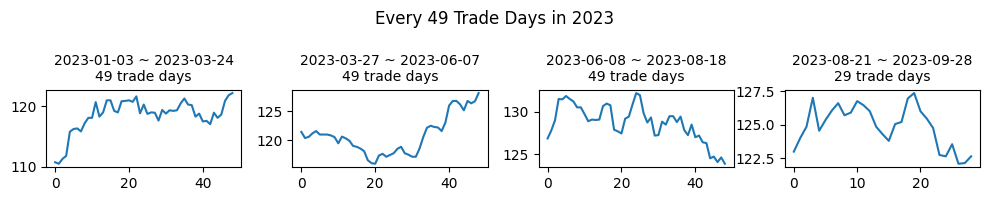

In [9]:
fig = plt.figure(figsize=(10, 2))

n = 49
interval = date[date.str.startswith('2023-')]
splits = [interval[i:i+n] for i in range(0, interval.shape[0], n)]
for i, split in enumerate(splits):
  beg_idx = split.index[0]
  end_idx = split.index[-1]
  close_price = adj_close[beg_idx:end_idx + 1].values

  plt.subplot(1, 4, i + 1)
  set_title(beg_idx, end_idx)
  plt.plot(close_price)

plt.suptitle(f'Every {n} Trade Days in 2023')
plt.tight_layout()
plt.show()

## Strategy
### Construction

In [10]:
def get_baseline_strategy_actions(prices: np.ndarray, beg_idx: int) -> list:
	actions = []

	for i in range(beg_idx, prices.shape[0]):
		action = baseline_strategy(prices[0:i], prices[i])
		actions.append(action)

	return actions

In [11]:
# optimal strategy
def get_best_actions(prices: np.ndarray, beg_idx: int) -> list:
  n = prices.shape[0] - beg_idx  # since we don't consider data before the target testing interval
  cash = np.zeros(n)
  stocks = np.zeros(n)
  action_logs = np.zeros((2, n))

  cash[0] = 1000
  stocks[0] = cash[0] / prices[beg_idx]
  action_logs[1][0] = 1

  for i in range(1, n):
    new_cash = stocks[i - 1] * prices[beg_idx + i]
    new_stock = cash[i - 1] / prices[beg_idx + i]

    if cash[i - 1] >= new_cash:
      cash[i] = cash[i - 1]
      action_logs[0][i] = 0
    else:
      cash[i] = new_cash
      action_logs[0][i] = -1

    if stocks[i - 1] >= new_stock:
      stocks[i] = stocks[i - 1]
      action_logs[1][i] = 0
    else:
      stocks[i] = new_stock
      action_logs[1][i] = 1

  idx = 0
  actions = []

  for i in range(n - 1, -1, -1):
    actions.append(action_logs[idx][i])
    if action_logs[idx][i] != 0:
      idx = 1 - idx

  return actions[::-1]

In [12]:
def get_rsi_strategy_actions(
  prices: np.ndarray, beg_idx: int,
  action_rise_above: int, action_fall_below: int,
  fast_ws: int, slow_ws: int
) -> list:
  actions = []

  fast_rsi = talib.RSI(prices, timeperiod=fast_ws)
  slow_rsi = talib.RSI(prices, timeperiod=slow_ws)

  for i in range(beg_idx, prices.shape[0]):
    if fast_rsi[i] > slow_rsi[i] and fast_rsi[i - 1] <= slow_rsi[i - 1]:
      actions.append(action_rise_above)
    elif fast_rsi[i] < slow_rsi[i] and fast_rsi[i - 1] >= slow_rsi[i - 1]:
      actions.append(action_fall_below)
    else:
      actions.append(0)

  return actions

In [13]:
def get_macd_strategy_actions(
  prices: np.ndarray, beg_idx: int,
  action_rise_above: int, action_fall_below: int,
  fastperiod: int, slowperiod: int, signalperiod: int
) -> list:
  actions = []

  macd, signal, _ = talib.MACD(prices, fastperiod, slowperiod, signalperiod)

  for i in range(beg_idx, prices.shape[0]):
    if signal[i] > macd[i] and signal[i - 1] <= macd[i - 1]:
      actions.append(action_rise_above)
    elif signal[i] < macd[i] and signal[i - 1] >= macd[i - 1]:
      actions.append(action_fall_below)
    else:
      actions.append(0)

  return actions

In [14]:
def get_rsi_bound_strategy_actions(
  prices: np.ndarray, beg_idx: int,
  ws: int
) -> list:
  actions = []

  rsi = talib.RSI(prices, timeperiod=ws)

  for i in range(beg_idx, prices.shape[0]):
    if rsi[i] > 60:
      actions.append(-1)
    elif rsi[i] < 40:
      actions.append(1)
    else:
      actions.append(0)

  return actions

### Fitting

In [15]:
def calculate_return_rate(prices: np.ndarray, actions: list) -> float:
	capital = 1000
	stock_holding = 0

	for i, action in enumerate(actions):
		curr_price = prices[i]
		if action == 1 and capital > 0:
			stock_holding = capital / curr_price
			capital = 0
		elif action == -1 and stock_holding > 0:
			capital = stock_holding * curr_price
			stock_holding = 0

	final = capital + stock_holding * curr_price
	return (final - 1000) / 1000

#### 1. Specify Fitting Interval

In [16]:
n = 49
fit_interval = date[date.str.startswith('2017-')]
history_beg = fit_interval.index[0] - n
fit_splits = [(i, i + n) for i in range(fit_interval.index[0], fit_interval.index[-1] + 1, n)]
split_num = len(fit_splits)

#### 2. RSI Strategy

In [17]:
action_rise_above = 1
action_fall_below = -1

best_fast_ws = [ None ] * 2
best_slow_ws = [ None ] * 2

for dir in range(2):
  max_rr = 0

  for fast_ws in range(2, 21):
    for slow_ws in range(fast_ws + 1, 41):
      avg_rr = 0

      for split in fit_splits:
        prices = adj_close[history_beg:split[1]].values
        trade_np_beg = split[0] - history_beg
        actions = get_rsi_strategy_actions(
          prices, trade_np_beg,
          action_rise_above, action_fall_below,
          fast_ws, slow_ws
        )
        avg_rr += calculate_return_rate(prices[trade_np_beg:], actions)
      avg_rr /= split_num

      if avg_rr > max_rr:
        max_rr = avg_rr
        best_fast_ws[dir] = fast_ws
        best_slow_ws[dir] = slow_ws

  print('[Original]' if dir == 0 else '[Inverse]')
  print(f'Maximized Average Return Rate: {max_rr * 100:.2f}%')
  print('Best Params:')
  print(f'- fast_ws: {best_fast_ws[dir]}')
  print(f'- slow_ws: {best_slow_ws[dir]}')

  action_rise_above, action_fall_below = action_fall_below, action_rise_above

[Original]
Maximized Average Return Rate: 2.27%
Best Params:
- fast_ws: 2
- slow_ws: 5
[Inverse]
Maximized Average Return Rate: 2.51%
Best Params:
- fast_ws: 9
- slow_ws: 32


#### 3. MACD Strategy

In [18]:
action_rise_above = 1
action_fall_below = -1

best_fastperiod = [ None ] * 2
best_slowperiod = [ None ] * 2
best_signalperiod = [ None ] * 2

for dir in range(2):
  max_rr = 0

  for signalperiod in range(2, 21):
    for fastperiod in range(signalperiod + 1, 31):
      for slowperiod in range(fastperiod + 1, 41):
        avg_rr = 0

        for split in fit_splits:
          prices = adj_close[history_beg:split[1]].values
          trade_np_beg = split[0] - history_beg
          actions = get_macd_strategy_actions(
            prices, trade_np_beg,
            action_rise_above, action_fall_below,
            fastperiod, slowperiod, signalperiod
          )
          avg_rr += calculate_return_rate(prices[trade_np_beg:], actions)
        avg_rr /= split_num

        if avg_rr > max_rr:
          max_rr = avg_rr
          best_fastperiod[dir] = fastperiod
          best_slowperiod[dir] = slowperiod
          best_signalperiod[dir] = signalperiod

  print('[Original]' if dir == 0 else '[Inverse]')
  print(f'Maximized Average Return Rate: {max_rr * 100:.2f}%')
  print('Best Params:')
  print(f'- fastperiod: {best_fastperiod[dir]}')
  print(f'- slowperiod: {best_slowperiod[dir]}')
  print(f'- signalperiod: {best_signalperiod[dir]}')

  action_rise_above, action_fall_below = action_fall_below, action_rise_above

[Original]
Maximized Average Return Rate: 2.36%
Best Params:
- fastperiod: 3
- slowperiod: 13
- signalperiod: 2
[Inverse]
Maximized Average Return Rate: 2.51%
Best Params:
- fastperiod: 7
- slowperiod: 9
- signalperiod: 4


#### 4. RSI Bound Strategy

In [19]:
max_rr = 0
best_ws = None

for ws in range(2, 41):
  avg_rr = 0

  for split in fit_splits:
    prices = adj_close[history_beg:split[1]].values
    trade_np_beg = split[0] - history_beg
    actions = get_rsi_bound_strategy_actions(
      prices, trade_np_beg,
      ws
    )
    avg_rr += calculate_return_rate(prices[trade_np_beg:], actions)
  avg_rr /= split_num

  if avg_rr > max_rr:
    max_rr = avg_rr
    best_ws = ws

print(f'Maximized Average Return Rate: {max_rr * 100:.2f}%')
print('Best Params:')
print(f'- ws: {best_ws}')

Maximized Average Return Rate: 2.70%
Best Params:
- ws: 4


### Testing

In [20]:
get_fitted_rsi_strategy_actions = partial(
  get_rsi_strategy_actions,
  action_rise_above=1,
  action_fall_below=-1,
  fast_ws=best_fast_ws[0],
  slow_ws=best_slow_ws[0]
)
get_fitted_rsi_inv_strategy_actions = partial(
  get_rsi_strategy_actions,
  action_rise_above=-1,
  action_fall_below=1,
  fast_ws=best_fast_ws[1],
  slow_ws=best_slow_ws[1]
)
get_fitted_macd_strategy_actions = partial(
  get_macd_strategy_actions,
  action_rise_above=1,
  action_fall_below=-1,
  fastperiod=best_fastperiod[0],
  slowperiod=best_slowperiod[0],
  signalperiod=best_signalperiod[0]
)
get_fitted_macd_inv_strategy_actions = partial(
  get_macd_strategy_actions,
  action_rise_above=-1,
  action_fall_below=1,
  fastperiod=best_fastperiod[1],
  slowperiod=best_slowperiod[1],
  signalperiod=best_signalperiod[1]
)
get_fitted_rsi_bound_strategy_actions = partial(
  get_rsi_bound_strategy_actions,
  ws=best_ws
)

In [21]:
n = 49
history_beg = date_idx.get_loc('2019-01-02')
test_interval = date[date.str.startswith('2023-')]
test_splits = [(i, i + n) for i in range(test_interval.index[0], test_interval.index[-1] + 1, n)]

In [22]:
strategies = {
  'Baseline': get_baseline_strategy_actions,
  'OPT': get_best_actions,
  'RSI': get_fitted_rsi_strategy_actions,
  'RSI_inv': get_fitted_rsi_inv_strategy_actions,
  'MACD': get_fitted_macd_strategy_actions,
  'MACD_inv': get_fitted_macd_inv_strategy_actions,
  'RSI_bound': get_fitted_rsi_bound_strategy_actions,
}
strategy_num = len(strategies)

action_list = [[] for _ in range(strategy_num)]
rr_list = [[] for _ in range(strategy_num)]

for split in test_splits:
  prices = adj_close[history_beg:split[1]].values
  trade_np_beg = split[0] - history_beg
  for i, strategy in enumerate(strategies.values()):
    actions = strategy(prices, trade_np_beg)
    rr = calculate_return_rate(prices[trade_np_beg:], actions)

    action_list[i] += actions
    rr_list[i].append(rr)

In [23]:
res = pd.DataFrame({ name: rr_log for name, rr_log in zip(strategies.keys(), rr_list) })
res = res.transpose() * 100
res['Total'] = res.sum(axis=1)
res['Average'] = res.mean(axis=1)

with pd.option_context('display.float_format', '{:.2f}%'.format):
  display(res)

,0,1,2,3,Total,Average
Baseline,4.13%,6.31%,-2.85%,-3.47%,4.11%,1.64%
OPT,27.79%,17.42%,15.10%,10.16%,70.47%,28.19%
RSI,-0.78%,4.96%,-1.82%,0.06%,2.42%,0.97%
RSI_inv,1.89%,-0.58%,-1.67%,0.61%,0.25%,0.10%
MACD,4.73%,0.59%,0.37%,-0.63%,5.06%,2.02%
MACD_inv,0.36%,5.34%,-2.46%,0.41%,3.65%,1.46%
RSI_bound,3.62%,-0.78%,0.45%,3.22%,6.51%,2.60%


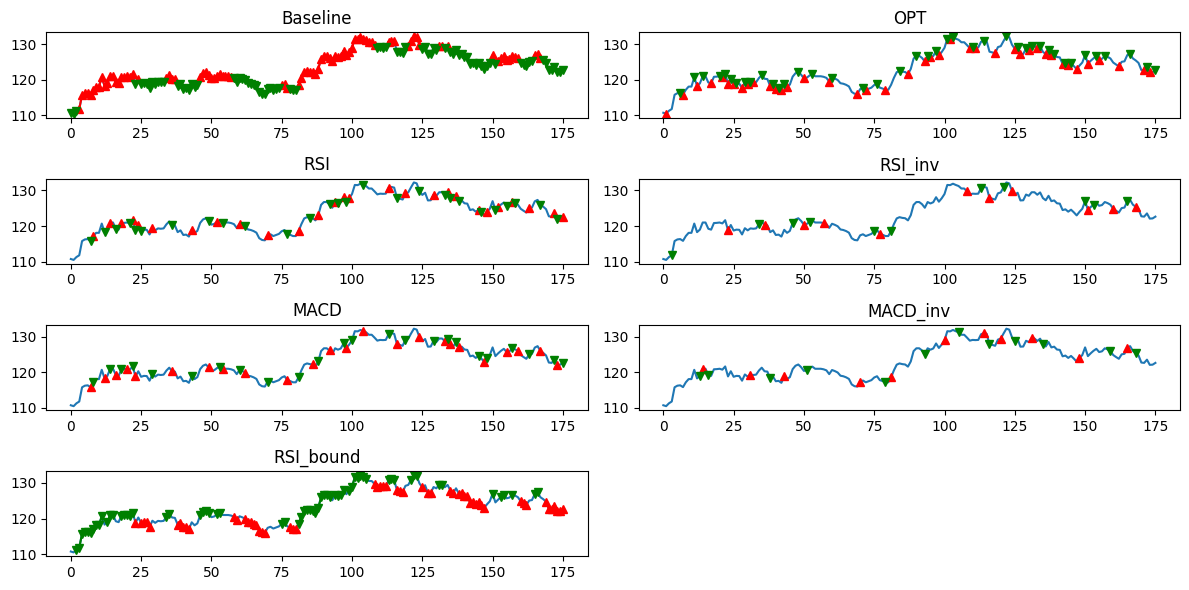

In [24]:
fig = plt.figure(figsize=(12, 6))

prices = adj_close[test_interval.index].values
for i, name in enumerate(strategies.keys()):
  plt.subplot(4, 2, i + 1)
  plt.title(name)
  plt.plot(prices)
  plot_actions(prices, action_list[i])

plt.tight_layout()
plt.show()